# JN00 · Look at the data first

The statistician Frederick Mosteller taught generations of analysts one rule before any other: **plot your data before you analyze it.** A picture shows you the shape, the surprises, and the questions — before a single formula gets a chance to mislead you.

So that is what this course does first. Before you learn what a function or a DataFrame is, in the next ten minutes you will **see** the dataset this whole course investigates — every building permit the City of Berkeley issued for two decades — three different ways. And before even that, you'll ask an AI to look at it for you.

**Curriculum notebook 0 — the front door.** Nothing to install; every cell runs in the free Colab tier.

### Running the cells

To run a cell, click it and press **Shift + Return**, or click the **run (▸) button** on the cell. The simplest way through any notebook here is to start at the top and run each cell in order, reading the output that appears beneath it.

Some of the computational cells may look complex right now — that's expected, and it's fine. **You don't need to understand every line yet;** the ideas become clear as you go. Run them, watch what they produce, and keep moving.

💡 Tip: the **Next** link opens the following notebook in a new tab. If Colab says you have too many sessions, just close the previous tab and continue.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← [Back to the course](https://berkeleybuild.com/data-science-curriculum.html)  |  Next: [JN0a · Why municipal data](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN0a_why_data.ipynb) →

## Step zero — ask an AI to look for you

In 2026 the honest first move with an unfamiliar dataset isn't code — it's a question. Open **Claude** (or Perplexity, ChatGPT, Gemini — whatever you have) and paste this:

> Here is a CSV of building permits from Berkeley, California (one row per permit, 2003–2025):
> `https://pub-2cee87f70da64080ab70ee0a34b55099.r2.dev/curriculum/data/permits_clean.csv`
> What is this data? What's in it? What would you check before trusting it? What questions about housing could it answer — and what questions can't it answer?

(If your AI can't fetch links, download the file and attach it instead.)

**Save the answer.** Seriously — paste it into a note. It will be good: today's AI reads a dataset fast and well. But here is the idea this whole course is built on: **an AI's read of your data is a hypothesis, not a result** — exactly like a city's official report, exactly like the charts you're about to make. By the last notebook (JN6b) you will have rebuilt this dataset's story yourself, checked it against the city's own filing to the state, and you can come back and **grade that saved answer**. That loop — get an answer fast, then earn the right to trust it — is the whole method.

## Load the data (one small file)

The cell below finds the course dataset — locally if you've cloned the project, otherwise it fetches one 2&nbsp;MB file. Then it shows the first three rows, exactly as they are.

In [1]:
# === LIGHT SETUP - one small file (~2 MB), not the full course bundle: fast first picture ===
from pathlib import Path
import sys, subprocess, urllib.request
try:
    import pyarrow  # parquet reader; Colab has pandas but sometimes not pyarrow
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow'], check=True)
DATA_URL = 'https://pub-2cee87f70da64080ab70ee0a34b55099.r2.dev/curriculum/data/permits_clean.parquet'
local = next((p/'data'/'processed'/'permits_clean.parquet'
              for p in [Path.cwd()] + list(Path.cwd().parents)
              if (p/'data'/'processed'/'permits_clean.parquet').exists()), None)
if local is None:
    local = Path('permits_clean.parquet')
    if not local.exists():
        # r2.dev sits behind Cloudflare, which 403s the default Python User-Agent
        req = urllib.request.Request(DATA_URL, headers={'User-Agent': 'Mozilla/5.0'})
        local.write_bytes(urllib.request.urlopen(req, timeout=60).read())
        print('fetched', local.name)
import pandas as pd
df = pd.read_parquet(local)
print(f'{len(df):,} permits x {len(df.columns)} columns')
df.head(3)

30,764 permits x 14 columns


,PermitNumber,StreetNumber,StreetName,StreetType,ParcelNumber,WorkType,OccType,ADU,UnitsAdded,NumberUnits,WorkDescription,IssuanceDate,FinaledStatus,FinaledDate
0,B2003-03513,2240,PRINCE,ST,052 155600100,Alteration,97R3,No data available,<NA>,<NA>,"REMOVE (E) 2ND FLOOR SUNROOM, MOVE (E) WINDOW....",NaT,Finaled,2021-05-14
1,B2003-04623,2670,PARKER,ST,055 184500600,Addition/Alteration,97R3,No data available,<NA>,<NA>,Raise 2 story house to create garage and stora...,2016-07-26,<NA>,NaT
2,B2004-04914,1333,HOPKINS,ST,060 241605100,Addition,97R3,No data available,<NA>,<NA>,CONVERT (E) 4-PLEX TO DUPLEX. ADD 122 S.F. AD...,2024-06-25,<NA>,NaT


That's the raw material: **one row per building permit**, with an address, what kind of work it allowed, how many homes it added, and the dates it was issued and finished. You just loaded thirty thousand of them in one line. (This is the *cleaned* copy — in JN1 you'll meet the city's original spreadsheets and learn what it took to get here.)

Now — Mosteller's rule. Three pictures before any analysis.

## Picture 1 — how much permit activity is there?

The simplest possible question: how many permits does Berkeley issue per year? One line of grouping, one bar chart.

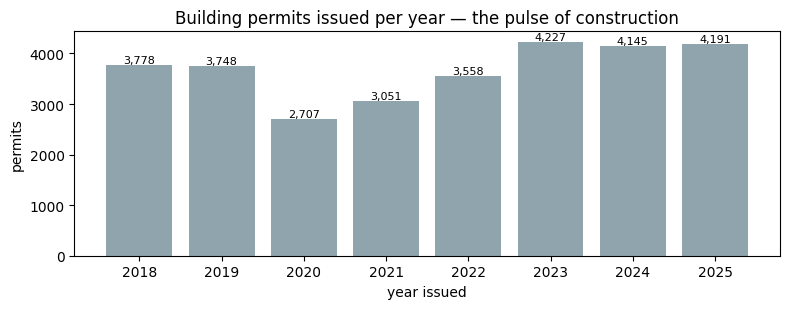

In [2]:
import matplotlib.pyplot as plt
issued = df['IssuanceDate'].dt.year
by_year = issued[(issued >= 2018) & (issued <= 2025)].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(by_year.index.astype(int).astype(str), by_year.values, color='#90a4ae')
for x, v in zip(by_year.index.astype(int).astype(str), by_year.values):
    ax.text(x, v + 40, f'{v:,}', ha='center', fontsize=8)
ax.set_title('Building permits issued per year — the pulse of construction')
ax.set_xlabel('year issued'); ax.set_ylabel('permits')
plt.tight_layout(); plt.show()

Thousands of permits a year, every year — most of them small (a water heater, a kitchen, a roof). The city's construction pulse is steady.

⚠ *One honest note:* the chart starts at 2018 because this feed covers permits **active from 2018 onward** — earlier years exist in the file only when an old permit stayed active, so charting them would show a fake decline. Knowing what your data *covers* before reading a trend from it is lesson one of looking at data — JN1 makes this precise.

## A catch you'd only find by looking — one building, many permits

Before the next picture, a real discovery made exactly the way Mosteller prescribes: by looking. Sort the home-adding rows by size and the same address keeps appearing. Here's one building's paper trail:

In [3]:
kitt = df[df['PermitNumber'].str.startswith('B2021-00008')]
kitt[['PermitNumber', 'StreetNumber', 'StreetName', 'WorkType', 'UnitsAdded']]

,PermitNumber,StreetNumber,StreetName,WorkType,UnitsAdded
12482,B2021-00008,2150,KITTREDGE,New,169
12483,B2021-00008-DEF01,2150,KITTREDGE,New,169
12484,B2021-00008-DEF02,2150,KITTREDGE,New,169
12485,B2021-00008-DEF04,2150,KITTREDGE,New,169
12486,B2021-00008-DEF05,2150,KITTREDGE,New,169
12487,B2021-00008-DEF08,2150,KITTREDGE,New,<NA>
12488,B2021-00008-DEF12,2150,KITTREDGE,New,<NA>
12489,B2021-00008-DEF16,2150,KITTREDGE,New,169
12490,B2021-00008-DEF18,2150,KITTREDGE,New,169
12491,B2021-00008-REV03,2150,KITTREDGE,New,169


One 169-home building at 2150 Kittredge — but a dozen permits (the base permit plus revisions `-REV` and deferred items `-DEF`), **each repeating the 169**. Sum the column blindly and this single building becomes ~2,000 phantom homes. Ten minutes of looking just saved us from a wildly wrong chart.

The quick fix: keep only **base permits** (the ones with exactly one `-` in the number). It's a rough rule — the course later builds the careful version — but it's honest enough for a first picture.

## Picture 2 — how many new homes get finished?

Now the question the whole course is about: of the base permits that **add homes** (`UnitsAdded` > 0), how many homes were **completed** (finaled) each year?

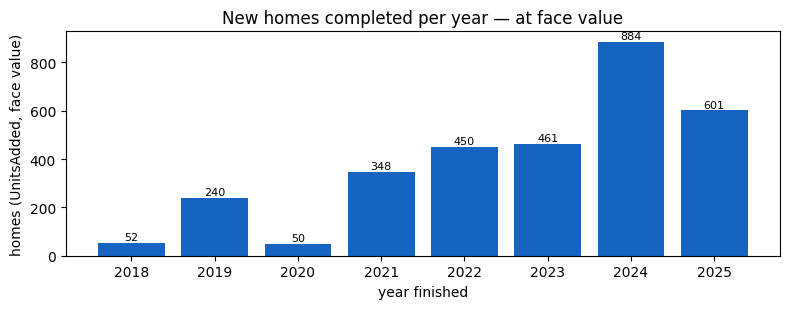

In [4]:
base = df[df['PermitNumber'].str.count('-') == 1]      # the Kittredge lesson: base permits only
homes = base[(base['UnitsAdded'] > 0) & base['FinaledDate'].notna()]
fin_year = homes['FinaledDate'].dt.year
by_fin = homes.groupby(fin_year)['UnitsAdded'].sum()
by_fin = by_fin[(by_fin.index >= 2018) & (by_fin.index <= 2025)]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(by_fin.index.astype(int).astype(str), by_fin.values, color='#1565c0')
for x, v in zip(by_fin.index.astype(int).astype(str), by_fin.values):
    ax.text(x, v + 12, f'{int(v):,}', ha='center', fontsize=8)
ax.set_title('New homes completed per year — at face value')
ax.set_xlabel('year finished'); ax.set_ylabel('homes (UnitsAdded, face value)')
plt.tight_layout(); plt.show()

A completely different shape: not a steady pulse but a **boom** — completions climb hard into the 2020s. That's the story this course investigates: *is the city building the homes it promised the state?*

⚠ *The face-value warning.* Even after the Kittredge fix, this chart trusts the `UnitsAdded` column as written — and one of the course's biggest lessons (**JN3**) is exactly how that column deceives in *both* directions: it can conjure homes that don't exist and hide real ones (the early years here are undercounted for exactly that reason). The true numbers differ from these bars. A quick picture is a **hypothesis** — like the AI's answer you saved, like the city's own report. That doesn't make it worthless; it makes it a starting point.

## Picture 3 — who builds Berkeley's housing? (the inversion)

Now the picture that changes how you read every housing headline. Take the home-adding permits and split them by **project size** — then count two different things: the **permits** in each size class, and the **homes** they add.

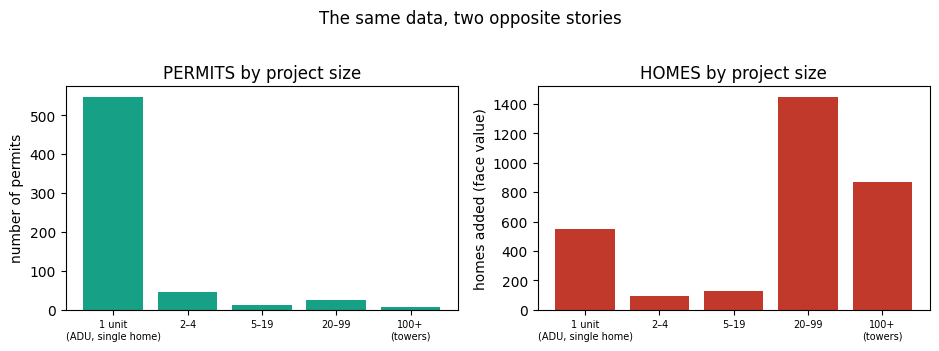

In [5]:
sized = homes.copy()                                    # base permits, homes added, finished
bins = [0, 1, 4, 19, 99, 100000]
labels = ['1 unit\n(ADU, single home)', '2–4', '5–19', '20–99', '100+\n(towers)']
sized['size_class'] = pd.cut(sized['UnitsAdded'], bins=bins, labels=labels)
counts = sized.groupby('size_class', observed=True).size()
units = sized.groupby('size_class', observed=True)['UnitsAdded'].sum()
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].bar(counts.index, counts.values, color='#16a085')
axes[0].set_title('PERMITS by project size'); axes[0].set_ylabel('number of permits')
axes[1].bar(units.index, units.values, color='#c0392b')
axes[1].set_title('HOMES by project size'); axes[1].set_ylabel('homes added (face value)')
for ax in axes:
    ax.tick_params(axis='x', labelsize=7)
plt.suptitle('The same data, two opposite stories', y=1.02)
plt.tight_layout(); plt.show()

**The inversion.** Most *permits* are tiny — a single backyard ADU, one home at a time. But most *homes* come from a handful of big buildings. Two plots of the same table, telling opposite stories — this is exactly why Mosteller said to plot first: no summary statistic would have shown you this.

It also plants a trap you'll spring later: because one permit can carry one home or a hundred and sixty-nine, **counting permits (or rows) is never the same as counting homes**. In **JN6a** you'll watch that exact mistake — and check whether the city's own report avoids it.

## Now change something — the whole point of a notebook

A chart in a newspaper is frozen. The cell below is not: it **computes**. Run it, then change `YEAR = 2023` to `2024` (or 2019, or 2025), press Shift + Return, and watch the answer recompute.

In [6]:
YEAR = 2023   # <-- change me, then re-run this cell (Shift + Return)
fin = homes[homes['FinaledDate'].dt.year == YEAR]
top = (fin[['StreetNumber', 'StreetName', 'StreetType', 'UnitsAdded']]
       .sort_values('UnitsAdded', ascending=False).head(10))
print(f'The 10 biggest completions of {YEAR} (face value):')
top.rename(columns={'UnitsAdded': 'homes'})

The 10 biggest completions of 2023 (face value):


,StreetNumber,StreetName,StreetType,homes
8389,2100,SAN PABLO,Ave,96
12361,3000,SAN PABLO,Ave,78
5359,2072,ADDISON,St,66
1260,2067,UNIVERSITY,Ave,50
7928,2009,ADDISON,St,45
9822,1717,UNIVERSITY,Ave,15
16906,2363,LE CONTE,Ave,9
14978,2980,COLLEGE,Ave,4
19275,1841,PRINCE,St,4
12884,2519,COLLEGE,Ave,2


Try a few years. Some years the list is towers; some years it's a parade of single ADUs. **That loop — compute → change → recompute — is the medium.** A notebook is an *instrument*, not a document: you can turn any dataset over in your hands, look at it ten different ways, and only then decide what's worth analyzing. Everything in this course happens inside that loop.

## Where this goes

By the end of the course, "looking at the data" becomes this — every completed housing project on a **live 3D map** you'll have built the record behind:

![Berkeley housing on a 3D MapLibre map](https://raw.githubusercontent.com/blockXblock/berkeley-housing-analysis/main/notebooks/curriculum/assets/berkeley_maplibre.jpg)

And the pictures get consequences: the project behind this course used exactly the method you're starting to rebuild it, checked the city's official housing report line by line, and published the differences — the **[live audit page](https://berkeleybuild.com/housing-audit.html)** is what these notebooks grow into.

In [7]:
# checkpoint - pinned to the FROZEN course data bundle, so it reproduces for every student
# (later notebooks explain this discipline; if you pointed the course at fresher data it would move)
assert len(df) == 30764
print('CHECKPOINT 00 PASS')
print('  you looked at the data three ways - and asked an AI to look - before any analysis')

CHECKPOINT 00 PASS
  you looked at the data three ways - and asked an AI to look - before any analysis


## Choose your path

- **In a hurry, or already know your way around code?** Jump straight to the real work: **[JN1 · Getting the data in the door](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN1_ingest.ipynb)** — where you'll meet the city's *original* messy spreadsheets and earn the clean table you just used.
- **New to all of this?** Take the on-ramp in order — **JN0a** (next, below) builds the vocabulary from zero: what a notebook is, a function, a DataFrame, a chart, an agent.

Either way: you've already done the most important thing. You looked first.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← [Back to the course](https://berkeleybuild.com/data-science-curriculum.html)  |  Next: [JN0a · Why municipal data](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN0a_why_data.ipynb) →